# 03 ? shared_hard training

**Objective:** Configure, launch and monitor one validation-selected EfficientNet-B0 reproduction run.

**Experiment:** Historical Flat versus Shared-Hard baseline reconstruction, seed 42.

**Config:** `configs/experiments/shared_hard/efficientnet_b0.yaml`

**Inputs:** Config, verified train/validation images; last checkpoint only when explicitly resuming.

**Outputs:** Run snapshot/environment/history/logs, immutable best.pt and last.pt generations, registry events.

**Mode:** Training workflow; opt-in disabled by default. Every input is loaded from disk; no other notebook's kernel state is required.

Use **Restart Kernel ? Run All**. Real training is disabled until the build handover is reviewed.


In [1]:
from pathlib import Path
import sys, os
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "configs/protocol.yaml").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import display, Markdown
from src.config import load_config
DATA_ROOT = os.environ.get("SKIN_CANCER_DATA_ROOT")
print("Dataset root:", Path(DATA_ROOT).expanduser().resolve() if DATA_ROOT else "NOT CONFIGURED ? set SKIN_CANCER_DATA_ROOT before image verification/training")


Dataset root: NOT CONFIGURED ? set SKIN_CANCER_DATA_ROOT before image verification/training


In [5]:
import os
from pathlib import Path

os.environ["SKIN_CANCER_DATA_ROOT"] = "/home/m-sazzad-h/skin-cancer-work"
DATA_ROOT = os.environ["SKIN_CANCER_DATA_ROOT"]

print("Dataset root:", Path(DATA_ROOT).expanduser().resolve())
print("data/raw exists:", (Path(DATA_ROOT) / "data/raw").exists())

Dataset root: /home/m-sazzad-h/skin-cancer-work
data/raw exists: True


In [9]:
from pathlib import Path

old_run = ROOT / "experiments/runs/shared_hard_efficientnet_b0_seed42"
backup_run = ROOT / "experiments/runs/shared_hard_efficientnet_b0_seed42_interrupted"

if old_run.exists():
    old_run.rename(backup_run)
    print("Moved old run to:", backup_run)
else:
    print("Old run directory not found.")

Moved old run to: /home/m-sazzad-h/Research-paper-continuation/experiments/runs/shared_hard_efficientnet_b0_seed42_interrupted


In [10]:
CONFIG_PATH = "configs/experiments/shared_hard/efficientnet_b0.yaml"
config = load_config(CONFIG_PATH)
display(config)

{'protocol_version': 'full30_baseline_v1',
 'seed': 42,
 'pretrained': 'imagenet',
 'dropout': 0.2,
 'classes': ['non_malignant', 'melanoma', 'bcc', 'scc'],
 'manifests': {'isic': 'data/manifests/isic2019_train_val_test_split_seed42.csv',
  'stage3': 'data/manifests/emb_stage03_dermoscopic_split_seed42.csv'},
 'expected_counts': {'isic': {'train': 17124,
   'validation': 3668,
   'test': 3668},
  'stage3': {'train': 594, 'validation': 127, 'test': 127}},
 'transforms': {'size': 224,
  'resize': 256,
  'crop_scale': [0.85, 1.0],
  'crop_ratio': [0.9, 1.1],
  'flip': 0.5,
  'rotation': 15.0,
  'jitter': [0.1, 0.1, 0.1, 0.02],
  'mean': [0.485, 0.456, 0.406],
  'std': [0.229, 0.224, 0.225]},
 'loader': {'batch_size': 64,
  'workers': 4,
  'pin_memory': True,
  'persistent_workers': True,
  'prefetch_factor': 2},
 'losses': {'flat': 'cross_entropy',
  'task1': 'cross_entropy',
  'task2': 'class_balanced_focal',
  'task3': 'weighted_cross_entropy',
  'beta': 0.9999,
  'gamma': 2.0,
  'task_

In [11]:
from pathlib import Path

DATA_ROOT = Path("/home/m-sazzad-h/skin-cancer-work")

print("DATA_ROOT =", DATA_ROOT)
print("data/raw exists:", (DATA_ROOT / "data/raw").exists())

DATA_ROOT = /home/m-sazzad-h/skin-cancer-work
data/raw exists: True


## Launch controls

After explicit Azure training authorization, set `RUN_TRAINING=True`. Use `RESUME=True` only for an interrupted run. A completed run cannot be overwritten. Other backbones remain locked until the EfficientNet-B0 comparison is reviewed.

In [12]:
RUN_TRAINING = True
RESUME = False
DEVICE = "cuda"

from src.training import train

result = train(
    config,
    data_root=DATA_ROOT,
    allow_training=RUN_TRAINING,
    resume=RESUME,
    device=DEVICE,
)

display(result)

Dataset root: /home/m-sazzad-h/skin-cancer-work
{"epoch": 1, "learning_rate": 0.0003, "train_loss": 0.5137709784903366, "train_task1_loss": 0.46030246336913727, "train_task2_loss": 0.17252721215024042, "train_task3_loss": 1.008637798482847, "val_task1_macro_f1": 0.7763648500046281, "val_task2_macro_f1": 0.616998735543746, "val_task3_macro_f1": 0.24075334694803724, "selection_score": 0.5447056441654704, "patience_counter": 0}
{"epoch": 2, "learning_rate": 0.0002991810233575568, "train_loss": 0.41213372788077784, "train_task1_loss": 0.4050912159657999, "train_task2_loss": 0.13116472921518085, "train_task3_loss": 0.7210574583699205, "val_task1_macro_f1": 0.759565596855106, "val_task2_macro_f1": 0.6239019407558734, "val_task3_macro_f1": 0.24403248924988055, "selection_score": 0.5425000089536199, "patience_counter": 1}
{"epoch": 3, "learning_rate": 0.0002967330663097039, "train_loss": 0.34972365799492755, "train_task1_loss": 0.3786248487525456, "train_task2_loss": 0.11853394330256384, "trai

{'experiment_id': 'shared_hard_efficientnet_b0_seed42',
 'architecture': 'efficientnet_b0',
 'system_type': 'shared_hard',
 'seed': 42,
 'config_path': 'configs/experiments/shared_hard/efficientnet_b0.yaml',
 'manifest_hash': 'bba1b8c962cc8b492afa09bdde517572690d764a4fc61d0200b19fe341ba824e',
 'start_time': '2026-09-11T05:03:36.719008+00:00',
 'end_time': '2026-09-11T05:59:26.569967+00:00',
 'best_epoch': 13,
 'selection_metric': 'mean_task1_task2_task3_macro_f1',
 'best_validation_score': 0.683243581876832,
 'checkpoint_path': 'models/checkpoints/shared_hard_efficientnet_b0_seed42/epoch_013_da2db014/best.pt',
 'status': 'completed'}

## Monitor and inspect checkpoint references

Re-run this cell to reload the current disk history. Validation selects the model; no internal-test predictions enter training.

{'experiment_id': 'shared_hard_efficientnet_b0_seed42',
 'architecture': 'efficientnet_b0',
 'system_type': 'shared_hard',
 'seed': 42,
 'config_path': 'configs/experiments/shared_hard/efficientnet_b0.yaml',
 'manifest_hash': 'bba1b8c962cc8b492afa09bdde517572690d764a4fc61d0200b19fe341ba824e',
 'start_time': '2026-09-11T05:03:36.719008+00:00',
 'end_time': '2026-09-11T05:59:26.569967+00:00',
 'best_epoch': 13,
 'selection_metric': 'mean_task1_task2_task3_macro_f1',
 'best_validation_score': 0.683243581876832,
 'checkpoint_path': 'models/checkpoints/shared_hard_efficientnet_b0_seed42/epoch_013_da2db014/best.pt',
 'status': 'completed'}

,epoch,learning_rate,train_loss,train_task1_loss,train_task2_loss,train_task3_loss,val_task1_macro_f1,val_task2_macro_f1,val_task3_macro_f1,selection_score,patience_counter
0,1,0.000300,0.513771,0.460302,0.172527,1.008638,0.776365,0.616999,0.240753,0.544706,0
1,2,0.000299,0.412134,0.405091,0.131165,0.721057,0.759566,0.623902,0.244032,0.542500,1
2,3,0.000297,0.349724,0.378625,0.118534,0.600712,0.793319,0.672258,0.306358,0.590645,0
3,4,0.000293,0.330742,0.377243,0.107267,0.533306,0.781727,0.668993,0.328335,0.593018,0
4,5,0.000287,0.275277,0.355631,0.097187,0.391743,0.760518,0.649777,0.332299,0.580865,1
5,6,0.000280,0.302830,0.354722,0.094088,0.504539,0.776367,0.658578,0.306181,0.580375,2
6,7,0.000271,0.264018,0.343960,0.089267,0.370856,0.760302,0.678923,0.548333,0.662519,0
7,8,0.000262,0.221368,0.323990,0.077064,0.278462,0.805875,0.670083,0.567719,0.681226,0
8,9,0.000251,0.224512,0.320512,0.074124,0.314068,0.753354,0.625944,0.428069,0.602456,1
9,10,0.000238,0.203479,0.310498,0.070974,0.208145,0.766071,0.666935,0.399343,0.610783,2


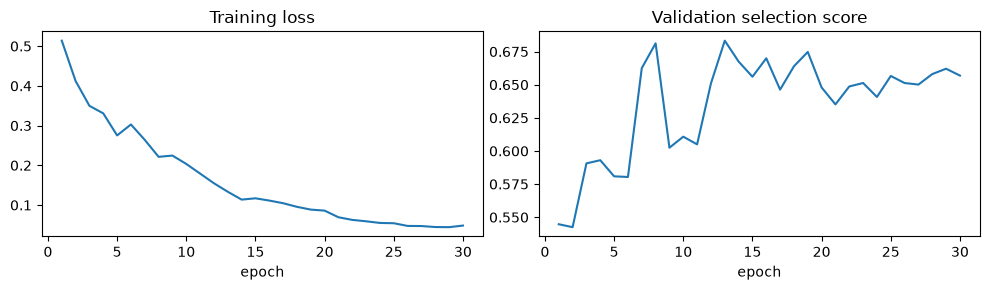

{'last': {'path': 'models/checkpoints/shared_hard_efficientnet_b0_seed42/epoch_030_0b7db83f/last.pt',
  'sha256': 'c04a0ae87163f9ef717060df5d2ea15e6662cf4bff52964c0a1ccfd379d18ea1'},
 'best': {'path': 'models/checkpoints/shared_hard_efficientnet_b0_seed42/epoch_013_da2db014/best.pt',
  'sha256': 'b6feaf58346f1e61600c09362bda948c7950a8f97b71098eff3a79c33c998c9a'}}

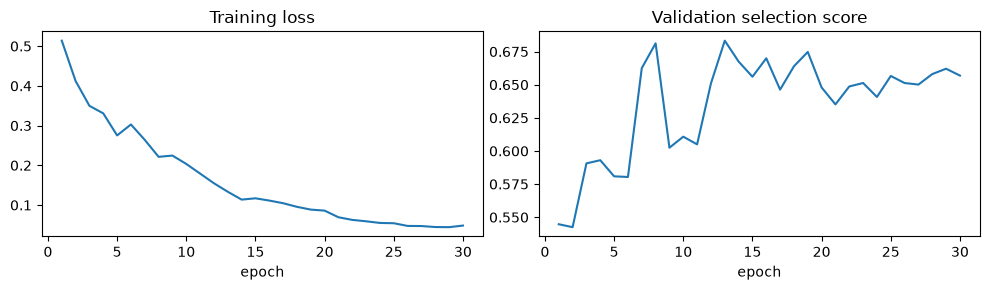

In [13]:
from src.reporting import run_status, plot_history
import json
summary, history = run_status(config["experiment_id"])
display(summary)
display(history)
figure = plot_history(history)
if figure is not None: display(figure)
refs = ROOT/"experiments/runs"/config["experiment_id"]/"checkpoints.json"
if refs.exists(): display(json.loads(refs.read_text()))
else: print("Checkpoint artifacts: NOT CREATED")

## Summary and next step

Review the status and metrics displayed above. Missing artifacts mean **not run**, never a successful reproduction. Generated artifacts are listed in the output cells; scientific results remain separate from historical reference values.

**Next:** `04_internal_test_evaluation.ipynb`. Preserve completed run directories, prediction files and checkpoint backups before continuing.
